In [1]:
import numpy as np
import matplotlib.pyplot as plt

### i. Calcul de la solution $u_h$ par éléments finis

(1) Écrire une fonction `FEM_1d` qui prend en entrée un vecteur $x$ représentant un maillage arbitraire $0 = x_0 < x_1 < \dots < x_N = 1$ (pas nécessairement uniformément distribuée !) et retourne la matrice assemblée $A$ de taille $(N - 1) \times (N - 1)$ et le vecteur $b$ avec

$$A_{i,j} = a(\varphi_i, \varphi_j) \quad 1 \leq i,j \leq N - 1$$
$$b_j = \ell(\varphi_j) \quad 1 \leq j \leq N - 1.$$

L'intégrale pour le second membre peut être calculée numériquement en utilisant la formule de quadrature au point milieu.

In [2]:
N : int = 10
random_nodes : np.ndarray = np.sort(np.random.rand(N-1))
random_mesh : np.ndarray = np.concatenate(([0], random_nodes, [1]))

def f(x : float):
    return 3/16*x**(-5/4)*(7*x+1)

def u(x: float):
    return x**(3/4) * (1-x)

def compute_b(x: np.ndarray) -> np.ndarray:
    N : int = len(x) - 1
    b : np.ndarray = np.zeros(N-1)
    for i in range(N - 1): # b est un vecteur qui contient les l(\varphi_j) pour 1 \leq j \leq N-1
        # On calcule le milieu du maillage : 
        mid_left_element : float = 1/2*(x[i+1] + x[i])
        mid_right_element : float = 1/2*(x[i+1] + x[i+2])

        h_left : float = x[i+1] - x[i]
        h_right : float = x[i+2] - x[i+1]

        # la formule de quadrature au point milieu donne l'approximation :
        left_element = h_left/2* f(mid_left_element)
        right_element =  h_right/2 * f(mid_right_element)
        b[i] = left_element + right_element
    return b


def FEM_1d(x : np.ndarray) -> tuple[np.ndarray,  np.ndarray] :
    N : int = len(x) - 1
    A : np.ndarray = np.zeros((N-1,N-1))
    for i in range(N-1):
        h_left : float = x[i+1] - x[i]
        h_right : float = x[i+2] - x[i+1]
        A[i,i] = 1/(h_left) + 1/(h_right)

        if i < N-2:
            A[i, i+1] = -1/h_right
            A[i+1, i] = -1/h_right
    
    b = compute_b(x)

    u_h = np.linalg.solve(A, b)
    # On inclut les conditions aux limites
    U_h = np.concatenate(([0], u_h, [0]))
    return (A, b, u_h, U_h)

## ii. Mesurer l’erreur

Remarquez que l’approximation par éléments finis $u_h$ est représentée par le vecteur $U_h$ via la combinaison linéaire $u_h = \sum_{i=0}^N (U_h)_i \varphi_i$. Définissons maintenant la norme d’énergie $\|\cdot\|_{H_0^1} := a(\cdot, \cdot)^{1/2}$. Utilisons l’orthogonalité de Galerkin, c’est-à-dire $a(u - u_h, v_h) = 0$ pour $v_h \in V_h$, pour montrer
$$\|u - u_h\|_{H_0^1}^2 = \|u\|_{H_0^1}^2 - \|u_h\|_{H_0^1}^2.$$

Dans la suite, calculez $\|u\|_{H_0^1}$ analytiquement et $\|u_h\|_{H_0^1}$ numériquement via $\|u_h\|_{H_0^1}^2 = U_h^T A U_h$.

(3) Ajouter à la fonction précédente **FEM_1d** une nouvelle sortie l’erreur d’énergie $\|u - u_h\|_{H_0^1}$.

In [3]:
# D'après la résolution analytique, on trouve que $\left|u\right|_{H^1_0}^2 = 3/5
# pour calculer l'erreur on modifie donc FEM_1d de la manière suivante : 

def FEM_1d_Err(x : np.ndarray) -> tuple[np.ndarray,  np.ndarray] :
    N : int = len(x) - 1
    A : np.ndarray = np.zeros((N-1,N-1))
    for i in range(N-1):
        h_left : float = x[i+1] - x[i]
        h_right : float = x[i+2] - x[i+1]
        A[i,i] = 1/(h_left) + 1/(h_right)

        if i < N-2:
            A[i, i+1] = -1/h_right
            A[i+1, i] = -1/h_right
    
    b = compute_b(x)

    u_h : np.ndarray = np.linalg.solve(A, b)

    E_h: float = np.sqrt(3/5 - u_h.T @ A @ u_h)

    # On inclut les conditions aux limites
    U_h = np.concatenate(([0], u_h, [0]))
    return (A, b, u_h, U_h, E_h)

iii. Convergence en utilisant des maillages uniformes

(4) Définir une fonction pour construire un maillage uniforme avec $N$ points.

In [4]:
def uniform_mesh(N : int) -> np.ndarray :
    return np.linspace(0, 1, N+1)

print(uniform_mesh(10))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


(5) Pour $N = 5, 10, 50, 100, 200$, calculez $U_h^{\text{unif}}$ et son erreur d'énergie associée $\|u - u_h^{\text{unif}}\|_{H_0^1}$. Tracez les erreurs d'énergie en fonction de $N$ sur une échelle log-log et estimez le taux de convergence. Comparez avec la convergence dans la norme $L^2$.

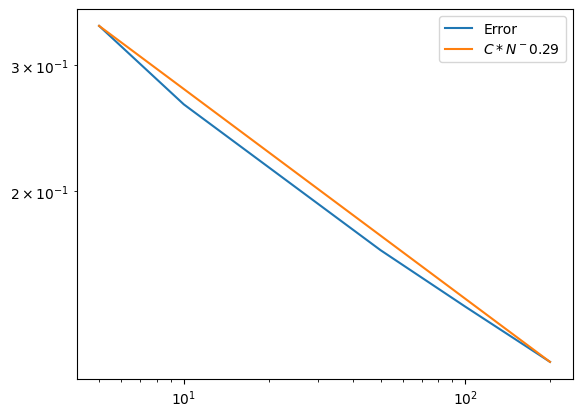

In [5]:
Steps : np.ndarray = np.array([5, 10, 50, 100, 200])

def convergence_H_1(Steps : np.ndarray) -> tuple[np.ndarray, float, np.ndarray]:

    Errors : np.ndarray = np.zeros_like(Steps, dtype=float)
    for (i, Step) in enumerate(Steps):
        mesh : np.ndarray = uniform_mesh(Step)
        (A, b, u_h, U_h, E_h_unif) = FEM_1d_Err(mesh)
        Errors[i] = E_h_unif

    slope : float = (np.log(Errors[-1]) - np.log(Errors[0]))/(np.log(Steps[-1]) - np.log(Steps[0]))
    convergence_rate : np.ndarray = Errors[-1]*(Steps/Steps[-1])**slope
    return Errors, slope, convergence_rate

def plot_results_convergence_H_1(convergence_H_1, Steps):
    
    Errors, slope, convergence_rate = convergence_H_1(Steps)
    fig, axes = plt.subplots()
    axes.loglog(Steps, Errors, label="Error")
    axes.loglog(Steps, convergence_rate, label=rf"$C*N^{slope:.2f}$")
    plt.legend()
    plt.show()

plot_results_convergence_H_1(convergence_H_1, Steps)

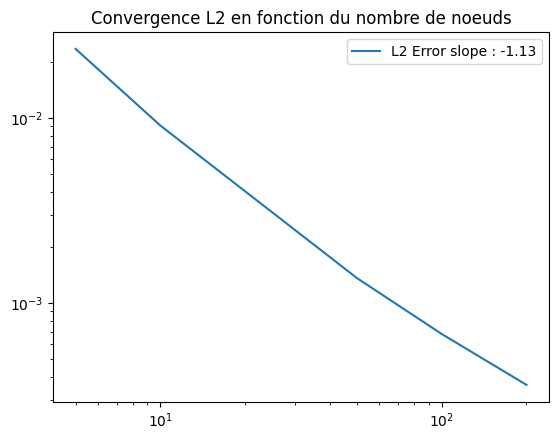

In [6]:
def compute_L2_error(U_h : np.ndarray, mesh : np.ndarray) -> float : # Calcul de l'erreur entre la solution approchée U_h et la solution exacte U sur le mesh
# On va calculer l'erreur sur chaque élément en utilisant la formule de quadrature du point milieu

    N : int = len(mesh) - 1
    h : np.ndarray = np.diff(mesh)
    integral : float = 0
    for i in range(N):
        U_h_mid : float = (U_h[i+1] + U_h[i])/2 # On calcule la solution approchée au milieu de l'élément
        node_mid : float = (mesh[i+1] + mesh[i])/2 # On calcule l'abscisse de l'élément du milieu
        U_mid : float = u(node_mid) # On calcule la solution exacte au milieu de l'élément
        integral += h[i] * (U_mid - U_h_mid)**2 
    return np.sqrt(integral)



def convergence_L2(Steps : np.ndarray) -> np.ndarray:

    # La convergence L^2 se calcule donc ainsi : 
    L2_Errors : np.ndarray = np.array(np.zeros_like(Steps), dtype=float)
    for (i, Step) in enumerate(Steps):
        mesh : np.ndarray = uniform_mesh(Step)
        res = FEM_1d_Err(mesh)
        U_h : np.ndarray = res[-2]
        L2_Error : float = compute_L2_error(U_h, mesh)
        L2_Errors[i] = L2_Error
    
    return L2_Errors

def plot_results_convergence_L2(convergence_L2, Steps):
    L2_Errors = convergence_L2(Steps)

    fig, axes = plt.subplots()
    slope : float = (np.log(L2_Errors[-1]) - np.log(L2_Errors[0]))/(np.log(Steps[-1]) - np.log(Steps[0]))
    axes.loglog(Steps, L2_Errors, label=f"L2 Error slope : {slope :.2f}")
    axes.set_title("Convergence L2 en fonction du nombre de noeuds")
    plt.legend()
    plt.show()

plot_results_convergence_L2(convergence_L2, Steps)

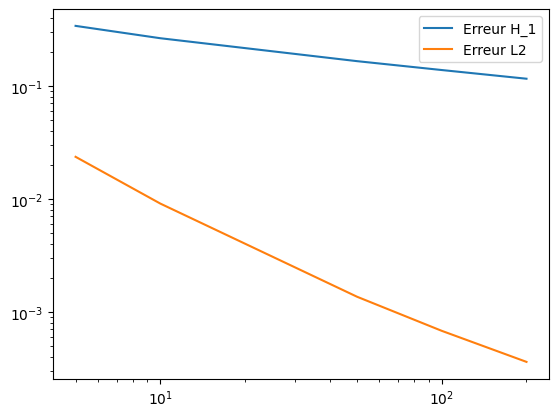

In [7]:
# Comparaison des convergences L^2 et H^1_0 : 
# Rappel Steps = [5, 10, 50, 100, 200]

def comparaison_convergences(Steps): # On utilise les fonctions auxiliares qu'on a défini auparavant. 
    Error_H_1,_ ,_ = convergence_H_1(Steps)
    Error_L2 : np.ndarray = convergence_L2(Steps)

    fig, axes = plt.subplots()

    axes.loglog(Steps, Error_H_1, label="Erreur H_1")
    axes.loglog(Steps, Error_L2, label="Erreur L2")

    plt.legend()
    plt.show()

comparaison_convergences(Steps)

##### Interprétation
Ce résultat est bien en accord avec le résultat théorique de l'inégalité de Poincaré valable sur $H^1_0$

### iv. Convergence en utilisant des maillages géométriques

Pour mieux capturer le comportement près de l’origine, nous définissons un maillage géométrique avec un facteur de déformation $\alpha > 1$:

$$x_i = \left(\frac{i}{N}\right)^\alpha, \quad i = 0, \dots, N.$$

Notez que pour $\alpha = 1$, le maillage est uniforme.

(6) Définir une fonction pour construire un maillage géométrique avec $N$ points de grille et un facteur de déformation $\alpha$. Calculer et tracer le maillage pour différentes valeurs de $\alpha$.

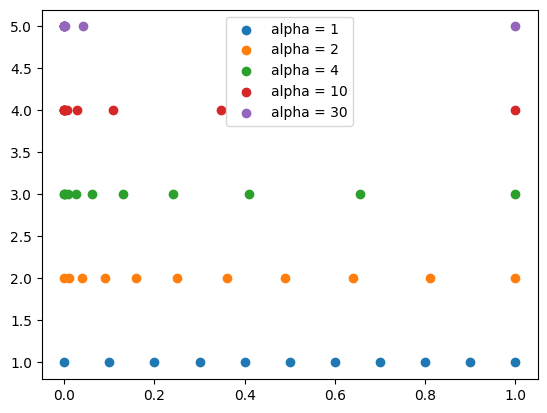

In [8]:
def geometric_mesh(N : int, alpha : float) -> np.ndarray:
    mesh : np.ndarray = np.zeros(N+1)
    for i in range(N+1):    # construction du maillage itérativement
        mesh[i] = (i/N)**alpha
    
    return mesh

def plot_meshes():
    alphas_test : list = [1, 2, 4, 10, 30]
    fig, axes = plt.subplots()
    for (i,alpha) in enumerate(alphas_test):
        mesh = geometric_mesh(10, alpha)
        axes.scatter(mesh, (i+1)*np.ones_like(mesh), label=f"alpha = {alpha}") # je représente les valeur des nodes dans un nuage de points


    plt.legend()
    plt.show()

plot_meshes()

(7) Pour $N = 5, 10, 50, 100, 200$ et un $\alpha$ fixe, par exemple 4, calculez $U_h^{\text{geo}}$ et son erreur d’énergie associée $\|u - u_h^{\text{geo}}\|_{H_0^1}$. Tracez les erreurs d’énergie en fonction de $N$ sur une échelle log-log et estimez le taux de convergence. Comparez avec la convergence dans la norme $L^2$.

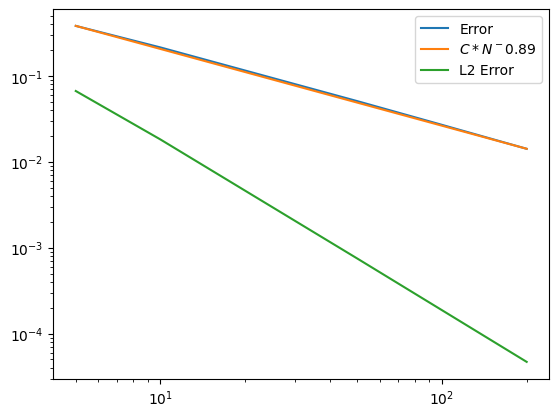

In [9]:
alpha : int = 4
def convergence_H_1_mesh_geom(alpha, Steps):
    Errors : np.ndarray = np.zeros_like(Steps, dtype=float) # On crée les vecteurs qui vont contenir l'historique des erreurs H^1
    L2_Errors : np.ndarray = np.zeros_like(Steps, dtype=float) # Ici l'historique des erreurs L2
    for i, Step in enumerate(Steps):
        mesh = geometric_mesh(Step, alpha)
        (A, b, u_h, U_h, E_h) = FEM_1d_Err(mesh)    # On appelle la fonction de résolution de la formulation variationnelle
        Errors[i] = E_h 
        L2_Errors[i] = compute_L2_error(U_h, mesh)  
    slope : float = (np.log(Errors[-1]) - np.log(Errors[0]))/(np.log(Steps[-1]) - np.log(Steps[0])) # Calcul de la pente en loglog de la courbe d'erreur H^1 en fonction du nombre de N
    convergence_rate : np.ndarray = Errors[-1]*(Steps/Steps[-1])**slope # Calcul de la fonction qui vérifie (ln(Error) = slope*ln(N) + constante) en passant à l'exponentielle 
    return Errors, L2_Errors, slope, convergence_rate


def plot_results_convergence_H1_mesh_geom(alpha):   # plot les résultat sur un graph
    Errors, L2_Errors, slope, convergence_rate = convergence_H_1_mesh_geom(alpha, Steps)
    fig, axes = plt.subplots()
    axes.loglog(Steps, Errors, label="Error")
    axes.loglog(Steps, convergence_rate, label=rf"$C*N^{slope :.2f}$" )
    axes.loglog(Steps, L2_Errors, label="L2 Error")

    plt.legend()
    plt.show()

plot_results_convergence_H1_mesh_geom(alpha)

(7) Pour $N = 5, 10, 50, 100, 200$ et un $\alpha$ fixe, par exemple 4, calculez $U_h^{\text{geo}}$ et son erreur d’énergie associée $\|u - u_h^{\text{geo}}\|_{H_0^1}$. Tracez les erreurs d’énergie en fonction de $N$ sur une échelle log-log et estimez le taux de convergence. Comparez avec la convergence dans la norme $L^2$.

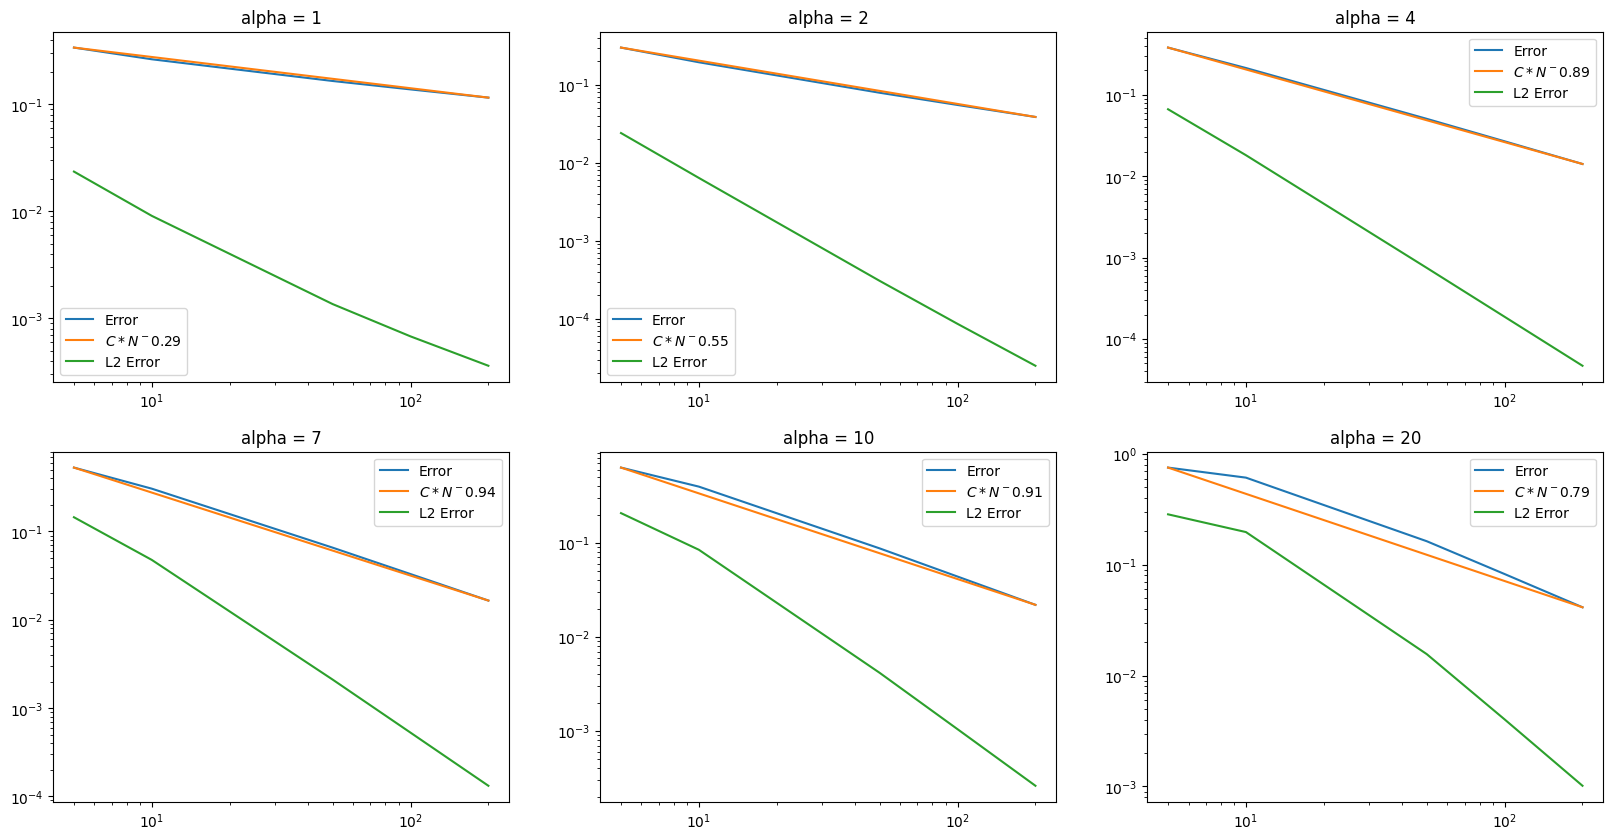

In [10]:
alphas : np.ndarray = np.array([1, 2, 4, 7, 10, 20])

def alpha_comparisons():

    fig, axes = plt.subplots(2,3, figsize=(20,10))
    for i, alpha in enumerate(alphas): # on répète le procédé pour chaque valeur de alpha
        Errors, L2_Errors, slope, convergence_rate = convergence_H_1_mesh_geom(alpha, Steps)
        ax = axes[i//3][i%3]
        ax.loglog(Steps, Errors, label="Error")
        ax.loglog(Steps, convergence_rate, label=rf"$C*N^{slope :.2f}$" )
        ax.loglog(Steps, L2_Errors, label="L2 Error")
        ax.set_title(f"alpha = {alpha}")
        ax.legend()
    plt.show()

alpha_comparisons()